# 00 — Unbiased evaluation under selective labels (FTTL total loss)

**What is being evaluated:** how well `model_v1_score` *discriminates* genuine total loss from
repairable — measured on the population we actually care about, not on contaminated labels or a
score-selected subsample.

The only trustworthy labels are **garage rows** (`model_v1_decision == 0`): scrapped cars are never
garage-verified, so their outcome is *forced to 1*. We contrast three readings of the same model:

| reading | rows | label | what it estimates |
|---|---|---|---|
| **naive** | all | observed (contaminated) | optimistically biased — partly rewards reproducing v1's forced positives |
| **verified** | garage only | true | honest, but for the garage *subpopulation* only |
| **selective-labels (IPS)** | garage only, reweighted | true | full-population discrimination — *within the overlap region* |

No oracle anywhere — "true label" is always the real garage outcome, never a scrapped car's unknown truth.

> **House style:** every figure below is built through `figstyle` (`src/figstyle.py`, spec in
> `notebook/FIGURE_TEMPLATE.md`) — one font, one colour order, saved to `figures/` as PNG.

**Papers:** P27 (selective labels), P3 (IPS / positivity), P6 (Heckman), P28 (PU prior via
garage-trained extrapolation), P24 (calibration caveat).

## 0. House style & load the log

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import figstyle
figstyle.apply()                       # fonts, sizes, grid, fixed colour order — apply once

PARQUET = ROOT / "src" / "data" / "synthetic" / "parquet"
log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")
log["claim_year"] = pd.to_datetime(log["claim_date"]).dt.year
print(f"claims_v1_log: {len(log):,} rows ({log.claim_year.min()}-{log.claim_year.max()})")
print("No oracle column: scrapped cars are never garage-verified (the SFP constraint).")

claims_v1_log: 3,374 rows (2022-2024)
No oracle column: scrapped cars are never garage-verified (the SFP constraint).


## 1. Three AUCs — with precision, recall & confusion matrix

AUC is threshold-free discrimination. But a discrimination number never travels alone here: at a
fixed operating threshold `τ` we also report **precision / recall / confusion matrix**, because
that is where the contamination becomes visible. `τ = 0.872` is the documented business scrap
threshold; on garage rows it selects a *verifiable* band of predicted-positives.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

L = log
scrap  = L.model_v1_decision == 1
garage = ~scrap
TAU = 0.872                              # documented business scrap threshold (score >= TAU -> scrap)

# ── propensity of SCRAP, from features only (never from the score itself) ──
feat = ["repair_to_value_ratio", "damage_severity", "vehicle_age_years", "mileage",
        "vehicle_type", "damage_location", "damage_type"]
Xd = pd.get_dummies(L[feat], drop_first=True).astype(float)
Xd = Xd.fillna(Xd.median(numeric_only=True))
e_raw = LogisticRegression(max_iter=1000).fit(Xd, L.model_v1_decision).predict_proba(Xd)[:, 1]
e = np.clip(e_raw, 0.02, 0.98)          # trim extreme propensities (variance control)
w = 1.0 / (1.0 - e)                     # IPS weight = 1 / P(garage)
gm = garage.values

# ── threshold-free discrimination (AUC) ──
naive_auc    = roc_auc_score(L.model_v1_observed_outcome.astype(int), L.model_v1_score)
verified_auc = roc_auc_score(L.loc[garage, "model_v1_observed_outcome"].astype(int),
                             L.loc[garage, "model_v1_score"])
sl_auc       = roc_auc_score(L.loc[garage, "model_v1_observed_outcome"].astype(int),
                             L.loc[garage, "model_v1_score"], sample_weight=w[gm])
print(f"naive AUC (contaminated label, all rows)          = {naive_auc:.3f}")
print(f"verified AUC (garage rows, unweighted)            = {verified_auc:.3f}")
print(f"selective-labels IPS AUC (reweighted to full pop) = {sl_auc:.3f}")
print(f"\nnaive - verified = {naive_auc - verified_auc:+.3f}: forced positives inflate the naive AUC.")

naive AUC (contaminated label, all rows)          = 0.806
verified AUC (garage rows, unweighted)            = 0.702
selective-labels IPS AUC (reweighted to full pop) = 0.812

naive - verified = +0.104: forced positives inflate the naive AUC.


In [3]:
# ── precision / recall / confusion matrix at the business threshold τ ──
def prc_cm(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    rec  = tp / (tp + fn) if (tp + fn) else np.nan
    return {"precision": prec, "recall": rec, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

rows = {}
rows["naive @ τ (all rows, contaminated label)"] = {
    "AUC": naive_auc,
    **prc_cm(L.model_v1_observed_outcome.astype(int), (L.model_v1_score >= TAU).astype(int))}
rows["verified @ τ (garage rows, true label)"] = {
    "AUC": verified_auc,
    **prc_cm(L.loc[garage, "model_v1_observed_outcome"].astype(int),
             (L.loc[garage, "model_v1_score"] >= TAU).astype(int))}
metrics = pd.DataFrame(rows).T[["AUC", "precision", "recall", "TN", "FP", "FN", "TP"]]
metrics = metrics.astype({"TN": int, "FP": int, "FN": int, "TP": int})
print("Contamination gap in precision =",
      f"{rows['naive @ τ (all rows, contaminated label)']['precision'] - rows['verified @ τ (garage rows, true label)']['precision']:+.3f}",
      "(naive minus verified) — the forced positives make naive precision look better than it is.")
metrics.round(3)

Contamination gap in precision = +0.151 (naive minus verified) — the forced positives make naive precision look better than it is.


,AUC,precision,recall,TN,FP,FN,TP
"naive @ τ (all rows, contaminated label)",0.806,0.933,0.470,1974,46,717,637
"verified @ τ (garage rows, true label)",0.702,0.782,0.187,1974,46,717,165


> **Why the TN / FP / FN columns are identical across the two rows — this is not a bug.** Both rows
> call predicted-positive `score ≥ τ`. Every scrapped car scores far above `τ`, so it is *always*
> predicted-positive and — carrying its forced label 1 — lands in **TP**. The two rows therefore share
> the *same* predicted-negative set (garage rows below `τ`) and the *same* garage-region false
> positives; the naive row differs **only** by the +472 forced-positive scrap rows piled onto TP.
> That single difference is what lifts precision 0.782 → 0.933. The gap *is* the contamination.

## 2. Positivity / overlap — the honest limit of IPS

IPS only recovers the full population where **0 < P(garage) < 1** for every region. Where the scrap
decision is (near-)deterministic, `P(garage) -> 0`: the weight `1/(1-e)` explodes and there are
almost no verified rows to reweight — IPS there is **extrapolation, not measurement** (the `np.clip`
above caps the weight, which controls variance but also *masks* the violation). So the IPS AUC is
honestly an estimate **for the overlap region**, not the deep scrap region. The plots below show how
much of the population sits in that safe band, and how much IPS mass rides on the extrapolation tail.

In [ ]:
p_garage = 1.0 - e
wg = w[gm] # gm = garage.values (not model-scrapped)
tail99 = wg > np.quantile(wg, 0.99)
print(f"scrap rate                                    = {scrap.mean():.1%}")
print(f"max IPS weight on any garage row              = {wg.max():.1f}")
print(f"top-1% heaviest garage weights carry          = {wg[tail99].sum() / wg.sum():.1%} of total IPS mass")
print(f"garage rows in the verifiable band score>=τ   = {int((L.loc[garage,'model_v1_score'] >= TAU).sum())}")
print(f"garage rows near the scrap decision score>=.999 = {int((L.loc[garage,'model_v1_score'] >= 0.999).sum())}")
print("\nReading: the fatter the weight tail and the fewer high-score garage rows, the more the IPS")
print("estimate leans on extrapolation rather than observed labels.")

scrap rate                                    = 14.0%
max IPS weight on any garage row              = 50.0
top-1% heaviest garage weights carry          = 18.5% of total IPS mass
garage rows in the verifiable band score>=τ   = 211
garage rows near the scrap decision score>=.999 = 0

Reading: the fatter the weight tail and the fewer high-score garage rows, the more the IPS
estimate leans on extrapolation rather than observed labels.


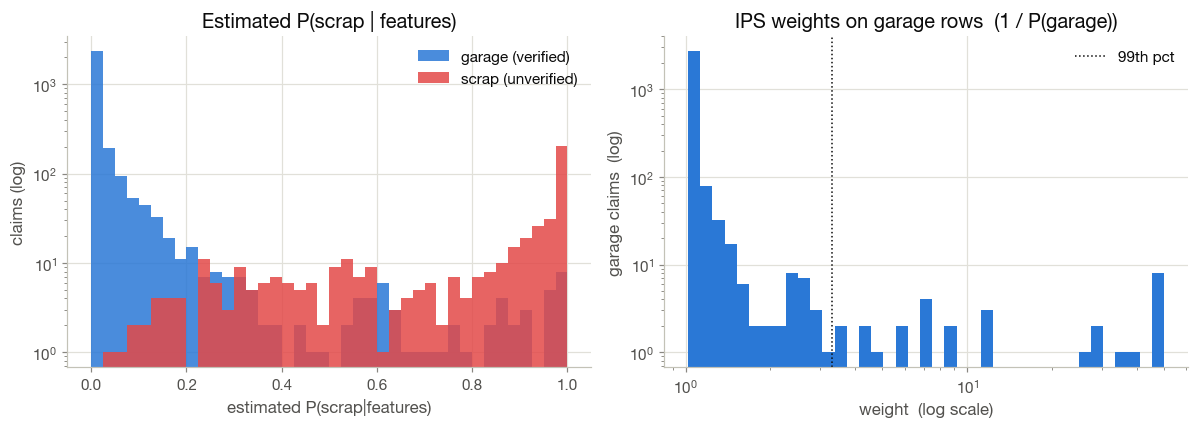

In [25]:
fig, ax = plt.subplots(1, 2, figsize=figstyle.FIG_2)
# wg = w[gm] 
# gm = garage.values (not model-scrapped)
# w = 1.0 / (1.0 - e)                     # IPS weight = 1 / P(garage)

# (1) propensity overlap: where do scrap vs garage rows live on P(scrap)?  (raw, un-clipped)
bins = np.linspace(0, 1, 41)
ax[0].hist(e_raw[gm],  bins=bins, color=figstyle.PRIMARY, alpha=0.85, label="garage (verified)")
ax[0].hist(e_raw[~gm], bins=bins, color=figstyle.CAUTION, alpha=0.85, label="scrap (unverified)")
ax[0].set_yscale("log") 
ax[0].set_title("Estimated P(scrap | features)")
ax[0].set_xlabel("estimated P(scrap|features)"); ax[0].set_ylabel("claims (log)")
ax[0].legend(frameon=False)

# (2) IPS weights on garage rows — heavy-tailed, so log-spaced bins + log axes
wbins = np.logspace(np.log10(wg.min()), np.log10(wg.max()), 40)
ax[1].hist(wg, bins=wbins, color=figstyle.PRIMARY)
ax[1].axvline(np.quantile(wg, 0.99), color=figstyle.INK, lw=1, ls=":", label="99th pct")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_title("IPS weights on garage rows  (1 / P(garage))")
ax[1].set_xlabel("weight  (log scale)"); ax[1].set_ylabel("garage claims  (log)")
ax[1].legend(frameon=False)

fig.tight_layout()
figstyle.save(fig, "00_positivity_overlap")
plt.show()

## 3. Stability — bootstrap CI & clip sensitivity

Under near-deterministic selection IPS is high-variance: a few heavy garage rows drive the estimate.
Two honest guards — a bootstrap confidence interval, and a sensitivity sweep over the clip level (AUC
is invariant to a global weight scale, so instability shows up as movement across clips / resamples,
not as a bias in level).

In [6]:
yg = L.loc[garage, "model_v1_observed_outcome"].astype(int).values
sg = L.loc[garage, "model_v1_score"].values
rng = np.random.default_rng(0)
boot = []
for _ in range(500):
    b = rng.integers(0, len(yg), len(yg))
    if yg[b].min() != yg[b].max():                 # need both classes present
        boot.append(roc_auc_score(yg[b], sg[b], sample_weight=wg[b]))
lo, hi = np.percentile(boot, [2.5, 97.5])
sl_ci = (lo, hi)
print(f"IPS AUC = {sl_auc:.3f}   95% bootstrap CI [{lo:.3f}, {hi:.3f}]   ({len(boot)} resamples)")

print("\nclip sensitivity (from the raw, un-clipped propensity):")
for c in [0.00, 0.02, 0.05, 0.10]:
    ec = np.clip(e_raw, c, 1 - c) if c > 0 else np.clip(e_raw, 1e-6, 1 - 1e-6)
    wc = 1.0 / (1.0 - ec)
    a = roc_auc_score(yg, sg, sample_weight=wc[gm])
    print(f"  clip={c:.2f}:  IPS AUC={a:.3f}   max weight={wc[gm].max():8.1f}")

IPS AUC = 0.812   95% bootstrap CI [0.767, 0.849]   (500 resamples)

clip sensitivity (from the raw, un-clipped propensity):
  clip=0.00:  IPS AUC=0.857   max weight=   200.9
  clip=0.02:  IPS AUC=0.812   max weight=    50.0
  clip=0.05:  IPS AUC=0.774   max weight=    20.0
  clip=0.10:  IPS AUC=0.752   max weight=    10.0


## 4. PU class prior — how many scrapped cars were likely repairable?

Train where the label is trustworthy (garage rows), extrapolate to the scrapped rows we can never
verify (P28-style PU extrapolation). This is an *estimate* from the garage-verified population, not
a measured value — the whole point of §2 is that the scrap region is unobserved.

In [7]:
clf_pu = LogisticRegression(max_iter=1000).fit(
    Xd[garage.values], L.loc[garage, "model_v1_observed_outcome"].astype(int))
pi_hat = clf_pu.predict_proba(Xd[scrap.values])[:, 1].mean()
n_scrap = int(scrap.sum())
n_harm  = int((1 - pi_hat) * n_scrap)
print(f"pi-hat (genuine total losses among scrapped) = {pi_hat:.1%}")
print(f"=> an estimated {1 - pi_hat:.1%} of scrapped cars were repairable.")
print(f"Estimated wrongful scraps in the log: ~{n_harm:,} of {n_scrap:,} scrapped.")
print("Naive PU treats every scrapped car as a positive (pi=1) — that is the contamination to correct.")

pi-hat (genuine total losses among scrapped) = 86.8%
=> an estimated 13.2% of scrapped cars were repairable.
Estimated wrongful scraps in the log: ~62 of 472 scrapped.
Naive PU treats every scrapped car as a positive (pi=1) — that is the contamination to correct.


## 5. The evaluation gap  *(dissertation figure)*

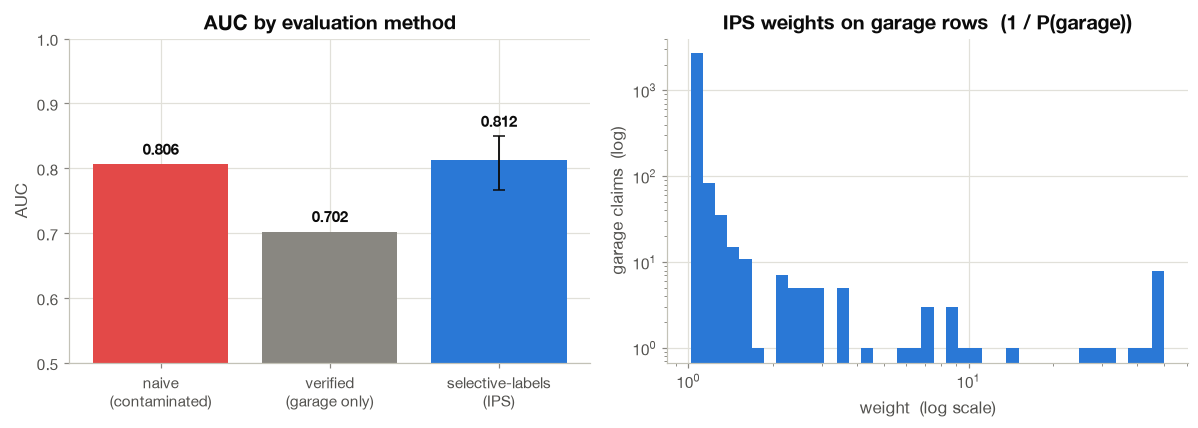

In [8]:
fig, ax = plt.subplots(1, 2, figsize=figstyle.FIG_2)

# (1) the headline: AUC by evaluation method — semantic colours (see FIGURE_TEMPLATE §2)
labels = ["naive\n(contaminated)", "verified\n(garage only)", "selective-labels\n(IPS)"]
vals   = [naive_auc, verified_auc, sl_auc]
colors = [figstyle.CAUTION, figstyle.NEUTRAL, figstyle.PRIMARY]
bars = ax[0].bar(labels, vals, color=colors)
# CI only on the IPS bar (the estimate that has one)
ax[0].errorbar(2, sl_auc, yerr=[[sl_auc - sl_ci[0]], [sl_ci[1] - sl_auc]],
               fmt="none", ecolor=figstyle.INK, capsize=4, lw=1.2)
ax[0].set_ylim(0.5, 1.0)
ax[0].set_title("AUC by evaluation method")
ax[0].set_ylabel("AUC")
tops = [naive_auc, verified_auc, sl_ci[1]]        # clear the CI cap on the IPS bar
for i, (v, top) in enumerate(zip(vals, tops)):
    ax[0].text(i, top + 0.015, f"{v:.3f}", ha="center", color=figstyle.INK, fontweight="bold")

# (2) supporting: IPS weight distribution on garage rows (heavy-tailed → log-log)
wbins = np.logspace(np.log10(wg.min()), np.log10(wg.max()), 40)
ax[1].hist(wg, bins=wbins, color=figstyle.PRIMARY)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_title("IPS weights on garage rows  (1 / P(garage))")
ax[1].set_xlabel("weight  (log scale)"); ax[1].set_ylabel("garage claims  (log)")

fig.tight_layout()
figstyle.save(fig, "00_evaluation_gap")
plt.show()

## Summary & caveats

- **Naive** log-AUC is optimistically biased — it partly rewards reproducing v1's forced positives;
  at `τ` its precision is inflated by the contaminated labels (§1 table).
- **Verified** AUC is unbiased for the garage *subpopulation* only — garage rows are a score-driven,
  non-random sample.
- **Selective-labels (IPS)** AUC reweights the verified estimate toward the full population and needs
  no oracle — **but only within the overlap region** (§2). Where the scrap decision is deterministic,
  `P(garage) -> 0` and IPS extrapolates; report it as an overlap-region estimate, never as the deep
  scrap region.
- **Positivity is the binding limitation.** The clean fix is not more reweighting but *creating*
  overlap — randomising a few high-score cars to garage (Build 05), or reporting Manski-style bounds
  for the unobserved region.
- **Stabilise & qualify:** weight clipping / self-normalised IPS, a bootstrap CI (§3), and a
  calibration pass on the propensity (P24) before trusting the weights.
- **OOT is also contaminated:** apply the identical correction to the v2 OOT holdout, not just
  train/test.